In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
##import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
imdb_customer_data = pd.read_csv(
r"/content/IMDB_data.csv"
)

In [5]:
imdb_customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         7032 non-null   int64  
 1   Gender             7032 non-null   int64  
 2   Senior Citizen     7032 non-null   int64  
 3   Partner            7032 non-null   int64  
 4   Dependents         7032 non-null   int64  
 5   Tenure Months      7032 non-null   int64  
 6   Phone Service      7032 non-null   int64  
 7   Multiple Lines     7032 non-null   int64  
 8   Internet Service   7032 non-null   int64  
 9   Online Security    7032 non-null   int64  
 10  Online Backup      7032 non-null   int64  
 11  Device Protection  7032 non-null   int64  
 12  Tech Support       7032 non-null   int64  
 13  Streaming TV       7032 non-null   int64  
 14  Streaming Movies   7032 non-null   int64  
 15  Contract           7032 non-null   int64  
 16  Paperless Billing  7032 

In [6]:
imdb_customer_data.drop("Unnamed: 0",axis=1,inplace=True)

In [7]:
imdb_customer_data.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')

In [8]:
## Splitting features and target
features , target = imdb_customer_data.drop(['Churn Score','Churn Value','Churn Label'],axis=1),imdb_customer_data["Churn Score"]

In [9]:
## train test split
X_train, X_temp, y_train, y_temp = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42
)


In [10]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [11]:
## regression model with weight
reg_model = Sequential(
    [
        Dense(32,activation = "relu",input_shape=(X_train.shape[1],),kernel_initializer=GlorotUniform),
        Dense(16,activation="relu",kernel_initializer=GlorotUniform),
        Dense(8,activation="relu"),
        ## output layer
        Dense(1,activation="linear")  ## regression problem
    ]
)

reg_model.compile(optimizer = "adam", loss ="mean_squared_error", metrics=["r2_score"] )

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
history = reg_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 111846.2422 - r2_score: -240.5646 - val_loss: 1545.9354 - val_r2_score: -2.3212
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1198.4597 - r2_score: -1.5884 - val_loss: 928.0405 - val_r2_score: -0.9937
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 868.0300 - r2_score: -0.8748 - val_loss: 787.5300 - val_r2_score: -0.6919
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 777.0389 - r2_score: -0.6782 - val_loss: 743.7291 - val_r2_score: -0.5978
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 739.4628 - r2_score: -0.5971 - val_loss: 718.5577 - val_r2_score: -0.5437
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 714.4129 - r2_score: -0.5430 - val_loss: 713.6572 - val_r2_score: -0.5332
Epoch 7/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 698.8417 - r2_score: -0.5094 - val_loss: 683.2926 - val_r2_score: -0.4679
Epoch 8/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

In [13]:
## experiment with different dropout rates

def create_dropout_model(dropout_rate):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(
            64,
            activation="relu",
            kernel_initializer=GlorotUniform()
        ),
        Dropout(dropout_rate),
        Dense(
            32,
            activation="relu",
            kernel_initializer=GlorotUniform()
        ),
        Dropout(dropout_rate),
        Dense(
            16,
            activation="relu",
            kernel_initializer=GlorotUniform()
        ),
        Dense(
                    8,
                    activation="relu",
                    kernel_initializer=GlorotUniform()
                ),
        Dense(
            1,
            activation="linear"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["r2_score"]
    )
    return model

In [14]:
# TEST DIFFERENT DROPOUT RATES

dropout_results = []

for rate in [0.0, 0.2, 0.3, 0.5]:
    model = create_dropout_model(rate)
    history = model.fit(
        X_train,
        y_train,
        validation_data=(
            X_val,
            y_val
        ),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    test_loss, test_mae = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )
    predictions = model.predict(
        X_test,
        verbose=0
    ).flatten()
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    dropout_results.append({
        "Dropout Rate": rate,
        "Test MAE": test_mae,
        "Test RMSE": rmse,
        "R2 Score": r2
    })


dropout_results_df = pd.DataFrame(
    dropout_results
)

print("\nDropout Experiment Results:")
print(dropout_results_df)


Dropout Experiment Results:
   Dropout Rate  Test MAE  Test RMSE  R2 Score
0           0.0  0.042775  21.107629  0.042776
1           0.2 -0.039508  21.996141 -0.039508
2           0.3 -0.000054  21.574675 -0.000054
3           0.5  0.074765  20.751929  0.074766


In [15]:
reg_model.predict
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)


model_checkpoint = ModelCheckpoint(
    "best_churn_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


final_model = create_dropout_model(
    dropout_rate=0.3
)


final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=200,
    batch_size=32,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/200
155/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 87115.6566 - r2_score: -189.6009
Epoch 1: val_loss improved from None to 1901.31738, saving model to best_churn_model.keras

Epoch 1: finished saving model to best_churn_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 26501.7598 - r2_score: -56.2383 - val_loss: 1901.3174 - val_r2_score: -3.0847
Epoch 2/200
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3878.4488 - r2_score: -7.3428
Epoch 2: val_loss improved from 1901.31738 to 1514.25732, saving model to best_churn_model.keras

Epoch 2: finished saving model to best_churn_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3199.5413 - r2_score: -5.9103 - val_loss: 1514.2573 - val_r2_score: -2.2531
Epoch 3/200
169/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2229.8402 - r2_score: -3.8173
Epoch 3: val_loss did not improve from 1514.25732
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2061.1611 - r2_score: -3.4517 - val_loss: 1547.4485 - val_r2_score: -

In [16]:
epochs_trained = len(
    final_history.history["loss"]
)

print(
    "\nTotal epochs actually trained:",
    epochs_trained
)

print(
    "Best validation loss:",
    min(final_history.history["val_loss"])
)

best_epoch = (
    np.argmin(
        final_history.history["val_loss"]
    ) + 1
)

print(
    "Best epoch:",
    best_epoch
)


Total epochs actually trained: 33
Best validation loss: 871.685546875
Best epoch: 23


In [18]:

best_model = tf.keras.models.load_model(
    "best_churn_model.keras"
)

print("\nBest model loaded successfully.")


Best model loaded successfully.


In [19]:
test_loss, test_mae = best_model.evaluate(
    X_test,
    y_test,
    verbose=0
)


y_pred = best_model.predict(
    X_test,
    verbose=0
).flatten()


mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)


print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

MAE  : 24.738697052001953
MSE  : 913.1927490234375
RMSE : 30.219079221965675
R²   : -0.9619920253753662


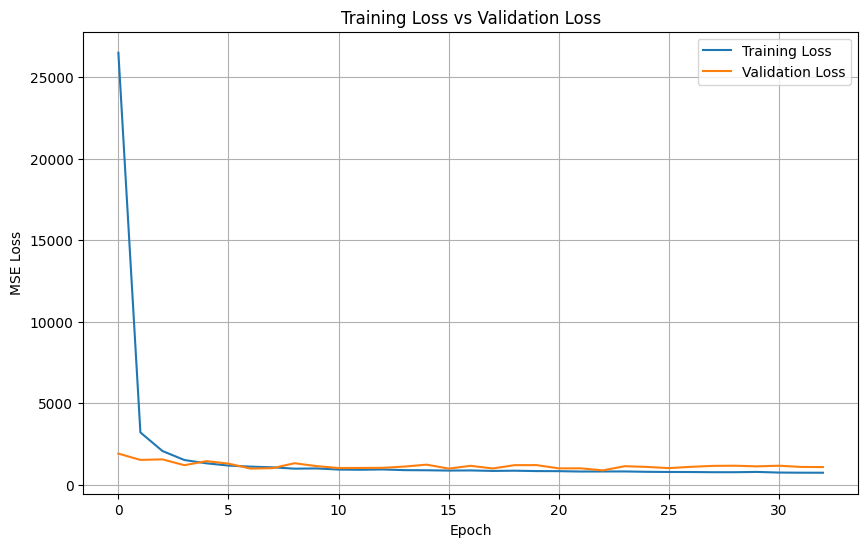

In [20]:

plt.figure(figsize=(10, 6))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title(
    "Training Loss vs Validation Loss"
)

plt.legend()
plt.grid(True)
plt.show()